In [1]:
import joblib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import librosa

from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, precision_recall_curve

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, Normalizer

from config import N_MELS

In [2]:
def show_precision_recall_curve(y_true, y_proba, punto_corte=0.5):
    prec, rec, thr = precision_recall_curve(y_true, y_proba)

    plt.plot(thr, rec[:-1], label='recall')
    plt.plot(thr, prec[:-1], label='precision')
    plt.xlabel('Punto de corte')
    plt.vlines(punto_corte, 0, 1, colors='red', linestyles='dashed', label='corte')
    plt.grid()
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 1.1, 0.1))
    plt.legend()
    plt.show()

def show_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matriz de Confusión');

## Pipelines

Se pueden probar la sustración espectral o wavelet denoising

In [3]:
pipeline_melspec = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('normalizer', Normalizer()),  ### Por la pipeline del dataset
    ('melspec', MelSpectrogramTransformer()),
    ('padder', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

pipeline_features = Pipeline([
    ('resampler', Resampler()),
    ('bandpass', BandPassFilter()),
    ('normalizer', Normalizer()),  ### Por la pipeline del dataset
    ('feature_extractor', FeatureExtractor())
])

## Audios de validación

### propios

In [4]:
path = './audios_propios/ciclos_energy_based'
files = os.listdir(path)

In [5]:
paths = [os.path.join(path, f) for f in files]

In [6]:
X_propios_melspec = pipeline_melspec.fit_transform(paths)

In [7]:
X_propios_features = pipeline_features.fit_transform(paths)

In [8]:
path_img = './audios_propios/ciclos_energy_based_mel_images'

X_propios_img = []
for f in files:
    img_path = os.path.join(path_img, f.replace('.wav', '.png'))
    img = Image.open(img_path).convert('L')  # Convertir a escala de grises
    img = np.array(img, dtype=np.float32)
    img = img.flatten()
    X_propios_img.append(np.array(img))

### coswara

Hay que segmentarlos!!!

In [9]:
dataset = 'ciclos_hl256_peak_t_aug_padmin_wd'

# Espectrogramas

## Random Forest

In [10]:
test_data = np.load(f'./dataset/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [11]:
melspec_rf = joblib.load(f'./modelos/{dataset}/melspec_rf.pkl')

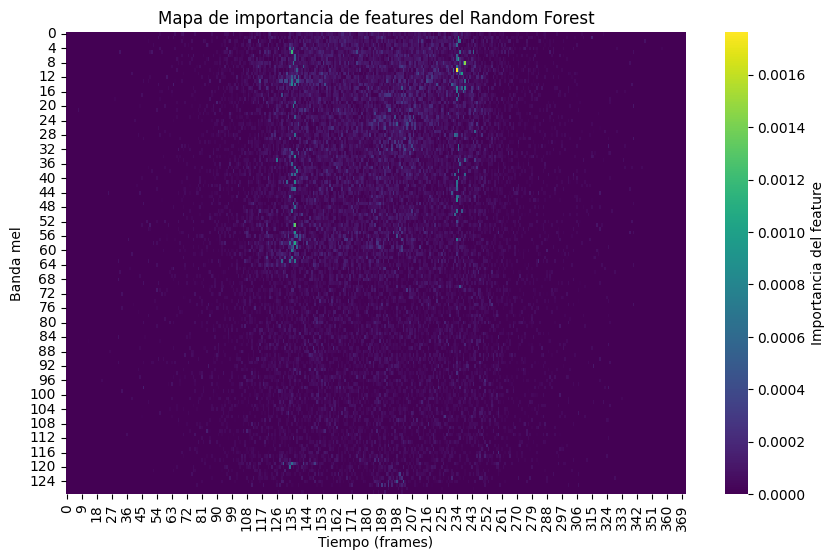

In [12]:
importances = melspec_rf.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap='viridis',
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Random Forest")
plt.show()

In [13]:
y_pred = melspec_rf.predict(X_test)
y_pred_proba = melspec_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.64      0.61      1452
           1       0.59      0.52      0.55      1398

    accuracy                           0.58      2850
   macro avg       0.59      0.58      0.58      2850
weighted avg       0.59      0.58      0.58      2850



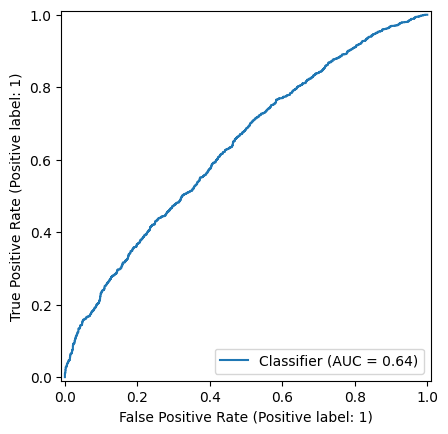

In [14]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

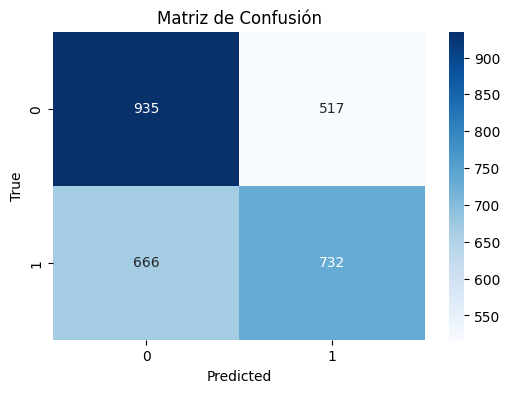

In [15]:
show_confusion_matrix(y_test, y_pred)

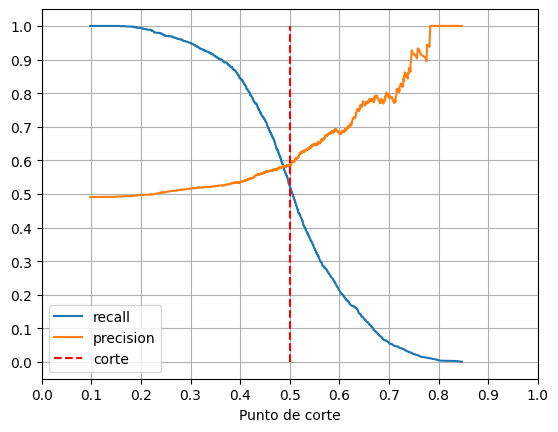

In [16]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

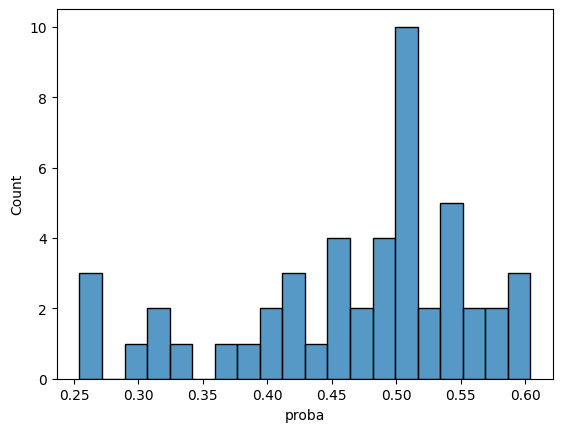

In [17]:
probas_propios = melspec_rf.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [18]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.488898
1,respiracion1_ciclo_2.wav,0.320032
2,respiracion1_ciclo_3.wav,0.604077
3,respiracion1_ciclo_4.wav,0.372101
4,respiracion1_ciclo_5.wav,0.504218
5,respiracion1_ciclo_6.wav,0.412933
6,respiracion1_ciclo_7.wav,0.593531
7,respiracion2_ciclo_1.wav,0.461139
8,respiracion2_ciclo_2.wav,0.540031
9,respiracion2_ciclo_3.wav,0.539820


## Gradient Boosting Classifier

In [19]:
melspec_gbc = joblib.load(f'./modelos/{dataset}/melspec_gbc.pkl')

In [20]:
importances = melspec_gbc.feature_importances_

n_mels = N_MELS
n_frames = importances.shape[0] // n_mels

importance_img = importances.reshape((n_mels, n_frames))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap="viridis",
    cbar_kws={'label': 'Importancia del feature'},
)
plt.xlabel("Tiempo (frames)")
plt.ylabel("Banda mel")
plt.title("Mapa de importancia de features del Gradient Boosting Classifier")
plt.show()

AttributeError: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'

In [21]:
y_pred = melspec_gbc.predict(X_test)
y_pred_proba = melspec_gbc.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.65      0.62      1452
           1       0.60      0.54      0.57      1398

    accuracy                           0.60      2850
   macro avg       0.60      0.60      0.60      2850
weighted avg       0.60      0.60      0.60      2850



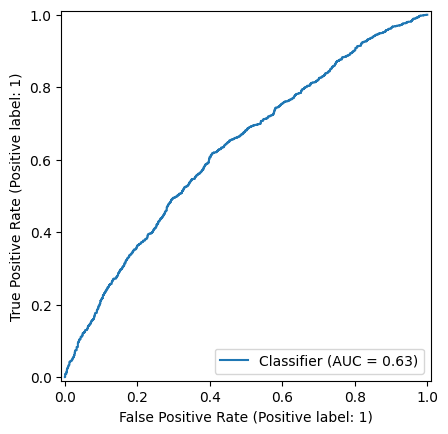

In [22]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

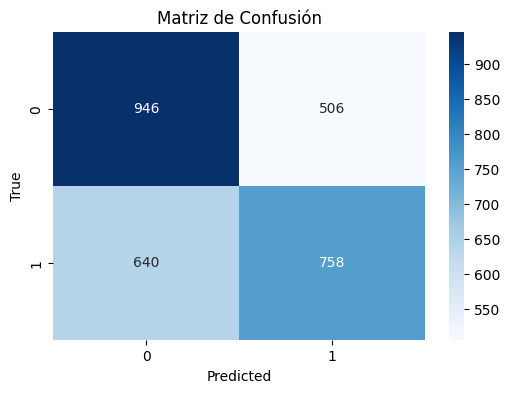

In [23]:
show_confusion_matrix(y_test, y_pred)

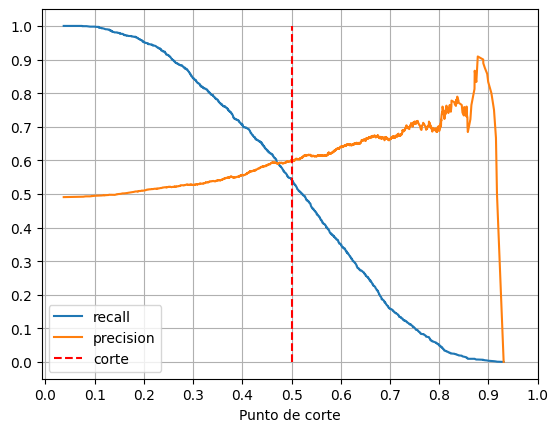

In [24]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

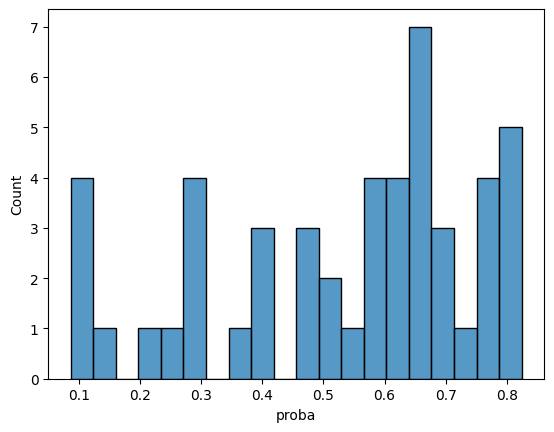

In [25]:
probas_propios = melspec_gbc.predict_proba(X_propios_melspec)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [26]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.645997
1,respiracion1_ciclo_2.wav,0.267474
2,respiracion1_ciclo_3.wav,0.681026
3,respiracion1_ciclo_4.wav,0.086285
4,respiracion1_ciclo_5.wav,0.620084
5,respiracion1_ciclo_6.wav,0.488187
6,respiracion1_ciclo_7.wav,0.795854
7,respiracion2_ciclo_1.wav,0.576457
8,respiracion2_ciclo_2.wav,0.757628
9,respiracion2_ciclo_3.wav,0.650807


# Features

## Random Forest

In [27]:
test_data = np.load(f'./dataset/{dataset}/test_features.npz')
X_test = test_data['X']
y_test = test_data['y']

In [28]:
feat_rf = joblib.load(f'./modelos/{dataset}/features_rf.pkl')

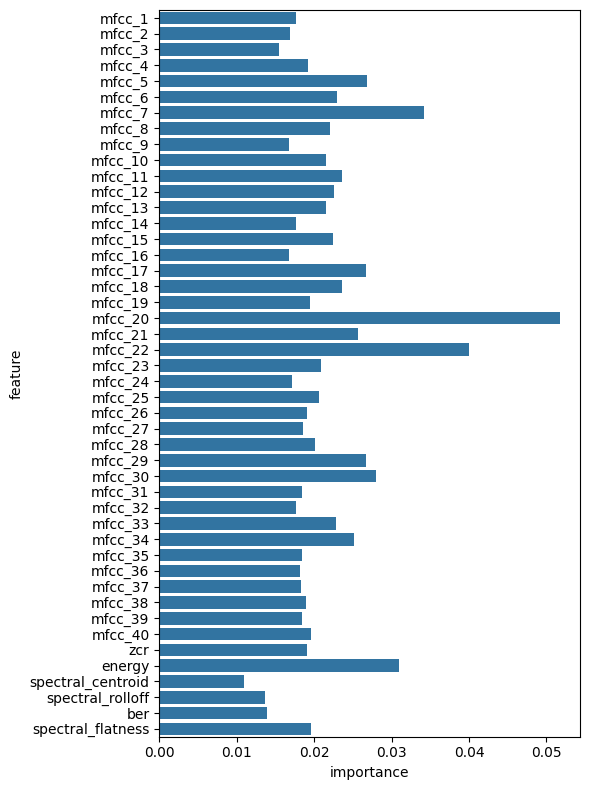

In [29]:
importances = feat_rf.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
})
plt.figure(figsize=(6, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.tight_layout();

In [30]:
y_pred = feat_rf.predict(X_test)
y_pred_proba = feat_rf.predict_proba(X_test)[:, 1]

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.86      0.70      1452
           1       0.72      0.36      0.48      1398

    accuracy                           0.62      2850
   macro avg       0.65      0.61      0.59      2850
weighted avg       0.65      0.62      0.59      2850



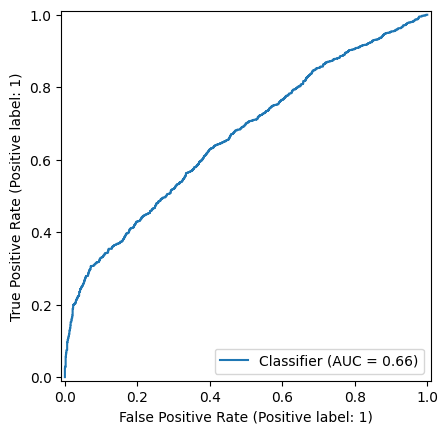

In [32]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

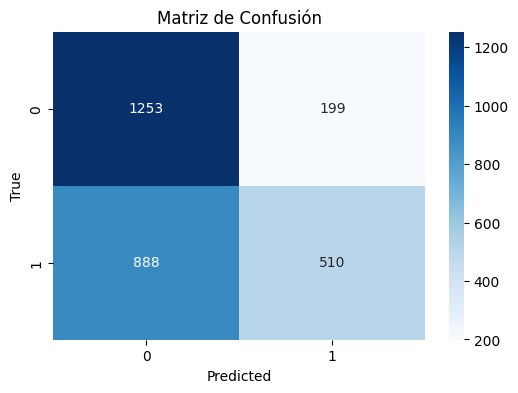

In [33]:
show_confusion_matrix(y_test, y_pred)

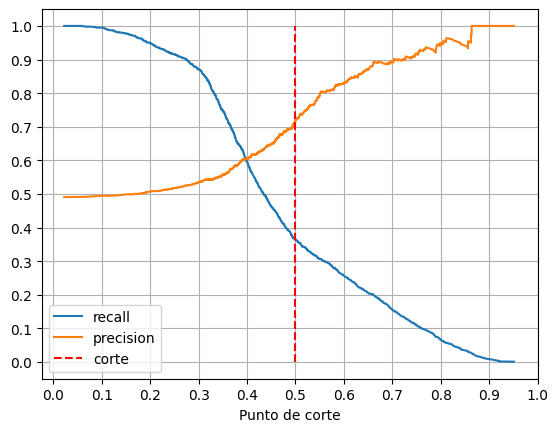

In [34]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [35]:
probas_propios = feat_rf.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

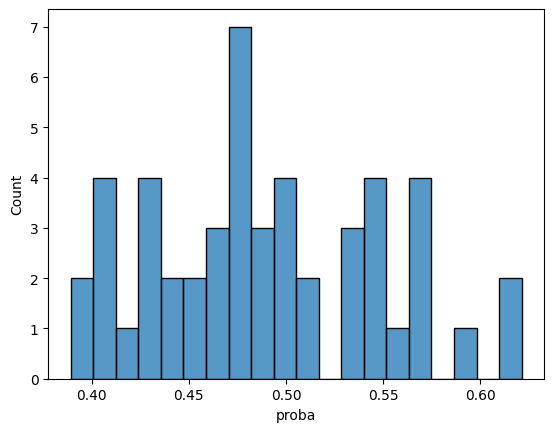

In [36]:
sns.histplot(df_probas, x='proba', bins=20);

In [37]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.541474
1,respiracion1_ciclo_2.wav,0.402633
2,respiracion1_ciclo_3.wav,0.553971
3,respiracion1_ciclo_4.wav,0.475598
4,respiracion1_ciclo_5.wav,0.427045
5,respiracion1_ciclo_6.wav,0.399590
6,respiracion1_ciclo_7.wav,0.389163
7,respiracion2_ciclo_1.wav,0.487986
8,respiracion2_ciclo_2.wav,0.535744
9,respiracion2_ciclo_3.wav,0.474171


## Gradient Boosting

In [38]:
feat_gbc = joblib.load(f'./modelos/{dataset}/features_gbc.pkl')

In [39]:
importances = feat_gbc.feature_importances_
columns = ['mfcc_' + str(i) for i in range(1, 41)] + ['zcr', 'energy', 'spectral_centroid', 'spectral_rolloff', 'ber', 'spectral_flatness']

importance_df = pd.DataFrame({
    'feature': columns,
    'importance': importances
})
plt.figure(figsize=(6, 8))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.tight_layout();

AttributeError: 'HistGradientBoostingClassifier' object has no attribute 'feature_importances_'

In [40]:
y_pred = feat_gbc.predict(X_test)
y_pred_proba = feat_gbc.predict_proba(X_test)[:, 1]

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.85      0.69      1452
           1       0.70      0.37      0.48      1398

    accuracy                           0.61      2850
   macro avg       0.64      0.61      0.59      2850
weighted avg       0.64      0.61      0.59      2850



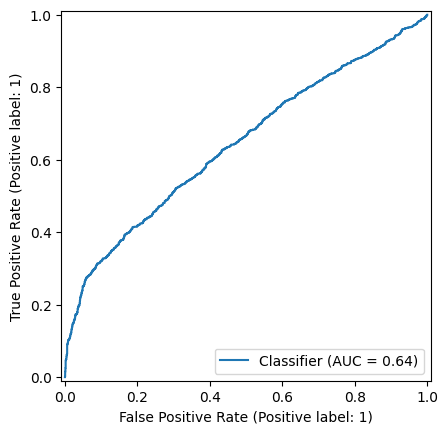

In [42]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

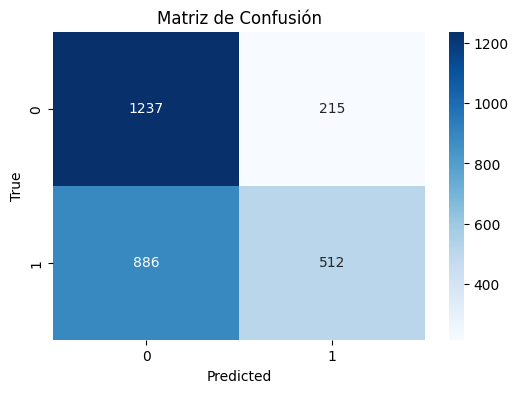

In [43]:
show_confusion_matrix(y_test, y_pred)

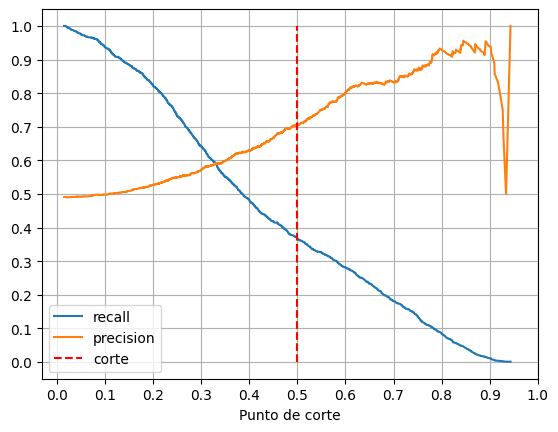

In [44]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

In [45]:
probas_propios = feat_gbc.predict_proba(X_propios_features)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})

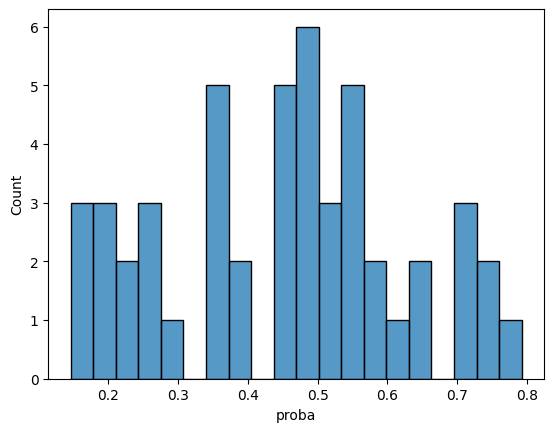

In [46]:
sns.histplot(df_probas, x='proba', bins=20);

In [47]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.648334
1,respiracion1_ciclo_2.wav,0.509357
2,respiracion1_ciclo_3.wav,0.536757
3,respiracion1_ciclo_4.wav,0.485283
4,respiracion1_ciclo_5.wav,0.176172
5,respiracion1_ciclo_6.wav,0.540869
6,respiracion1_ciclo_7.wav,0.146624
7,respiracion2_ciclo_1.wav,0.248939
8,respiracion2_ciclo_2.wav,0.497935
9,respiracion2_ciclo_3.wav,0.360141


# Imagenes

In [48]:
def load_image_dataset_pil(img_dir, to_gray=True, flatten=False, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if to_gray:
            img = img.convert('L')  # convierte a escala de grises (1 canal)
        
        if target_size:
            img = img.resize(target_size)
        
        img = np.array(img, dtype=np.float32)
        
        if flatten:
            img = img.flatten()
        
        X.append(img)
        y.append(row['label'])
    
    return np.array(X), np.array(y)

In [49]:
test_dir = f'./dataset/{dataset}/mel_images/test'
X_test, y_test = load_image_dataset_pil(test_dir, to_gray=True, flatten=True)

In [50]:
img_rf = joblib.load(f'./modelos/{dataset}/melspec_img_rf.pkl')

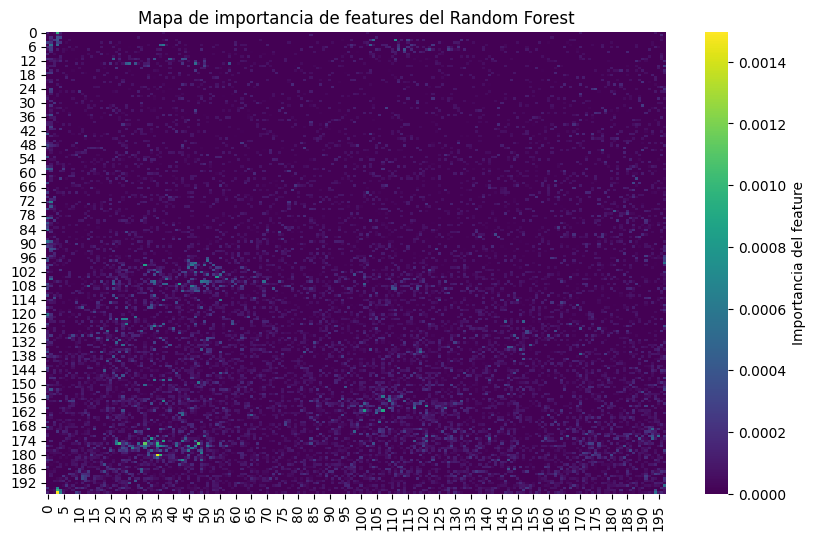

In [51]:
importances = img_rf.feature_importances_
importance_img = importances.reshape((197, 198))

plt.figure(figsize=(10, 6))
sns.heatmap(
    importance_img,
    cmap='viridis',
    cbar_kws={'label': 'Importancia del feature'},
)
plt.title("Mapa de importancia de features del Random Forest")
plt.show()

In [52]:
y_pred = img_rf.predict(X_test)
y_pred_proba = img_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.74      0.42      0.54       663
           1       0.58      0.85      0.69       633

    accuracy                           0.63      1296
   macro avg       0.66      0.63      0.61      1296
weighted avg       0.66      0.63      0.61      1296



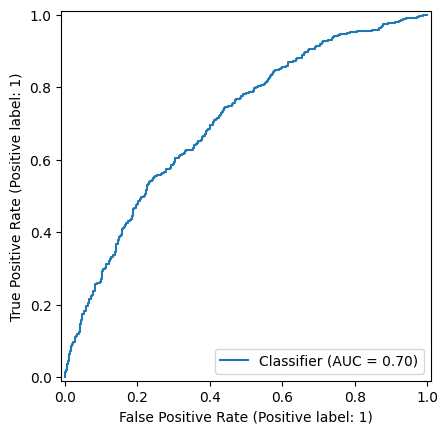

In [53]:
RocCurveDisplay.from_predictions(y_test, y_pred_proba);

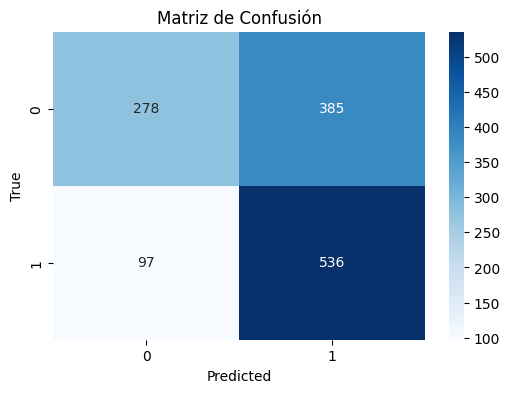

In [54]:
show_confusion_matrix(y_test, y_pred)

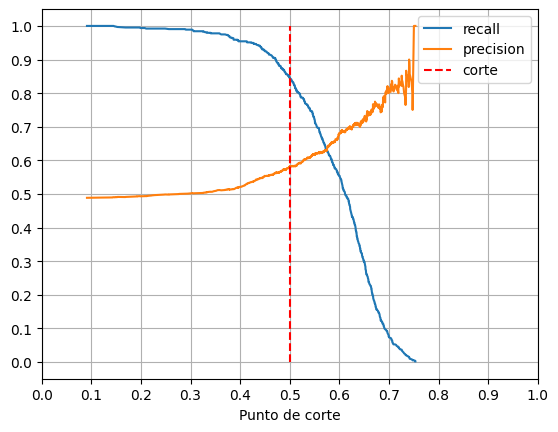

In [55]:
show_precision_recall_curve(y_test, y_pred_proba, punto_corte=0.5)

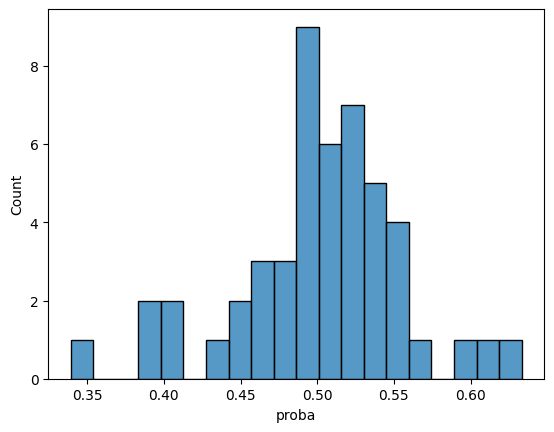

In [56]:
probas_propios = img_rf.predict_proba(X_propios_img)[:, 1]
df_probas = pd.DataFrame({
    'file': files,
    'proba': probas_propios
})
sns.histplot(df_probas, x='proba', bins=20);

In [57]:
df_probas

,file,proba
0,respiracion1_ciclo_1.wav,0.524362
1,respiracion1_ciclo_2.wav,0.399307
2,respiracion1_ciclo_3.wav,0.516575
3,respiracion1_ciclo_4.wav,0.339239
4,respiracion1_ciclo_5.wav,0.527310
5,respiracion1_ciclo_6.wav,0.433477
6,respiracion1_ciclo_7.wav,0.552249
7,respiracion2_ciclo_1.wav,0.477418
8,respiracion2_ciclo_2.wav,0.488136
9,respiracion2_ciclo_3.wav,0.536245
